<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_1_Benchmarking_Classification_Algorithms_for_Credit_Risk_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Benchmarking Classification Algorithms for Credit Risk (Lending Club Edition)**

Part 1 of the credit risk series. It requires the output of *Part 0: Credit Risk Data Foundation* (`lc_clean.pkl`).

---

* Project Overview & Data Source

Data Source: This project uses the Lending Club loan [dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club), prepared in Part 0: 2.26 million US consumer loans issued between 2007 and 2018. The modeling sample is the set of **36-month loans issued 2010–2015** whose outcome is known: either fully repaid or charged off.

The Business Problem: A classification problem arises when the goal is to sort observations into predefined groups rather than to predict a continuous value, for example whether a loan applicant will default. In credit risk, the model's output is a **probability of default (PD)**. The lender applies a threshold to the PD to approve or decline applicants, sets prices with it, and holds capital against it. Choosing the right algorithm is a trade-off between predictive power, calibration, speed and interpretability.

Objective: To benchmark seven classification algorithms on the same PD problem under a **realistic, out-of-time** validation design, and compare them with Lending Club's own credit grade as an external benchmark:
1. Random Forest;
2. XGBoost;
3. LightGBM;
4. CatBoost;
5. Logistic Regression (WOE scorecard);
6. LASSO;
7. Support Vector Machine.

---

* The Logic & Methodology

Target Definition: Default = the loan was charged off during its 36-month life. Restricting the sample to 36-month loans issued up to 2015 means almost every loan has reached maturity by the March 2019 snapshot. The target is therefore complete, with no censoring bias.

Out-of-Time Validation: Models are trained on loans issued **2010–2014** and tested on loans issued in **2015**. This mimics real deployment: a model built on past vintages must rank the next vintage. It is stricter than a random split, because the 2015 borrowers are riskier than the earlier ones (Part 0 showed the default share rising over time).

Leakage Control: Only information known at the application date is used. Lending Club's own `grade`, `sub_grade` and `int_rate` are excluded from the features, because they are Lending Club's risk assessment. They serve instead as the **external benchmark** our models must beat. The borrower's state (`addr_state`) is excluded as a potential proxy for protected characteristics.

Data Routing by Algorithm Architecture:
1. **Tree-based models** (Random Forest, XGBoost, LightGBM, CatBoost) are trained on raw, unscaled data, using their built-in handling of missing values and non-linear splits.
2. **Logistic Regression** is trained on WOE-transformed data. The WOE bins are fitted **on the training set only**, to prevent leakage.
3. **LASSO and SVM** are trained on standardized, imputed data, so that penalties and distances treat all features equally.

Imbalance Handling: No class weights are used. Weights change the *scale* of predicted probabilities, not their *ranking*. They would leave AUC and KS unchanged but make the PDs uncalibrated, and calibration (measured here by the Brier score) matters for pricing and capital.

---

* Results & Business Impact

Gradient Boosting Wins, but Only Just: On the unseen 2015 vintage (283,026 loans), **XGBoost (AUC 0.671)**, LightGBM (0.670) and CatBoost (0.670) form a clear top group. They lead the WOE logistic scorecard (0.653) by about **0.017 AUC** (0.035 Gini points).

The Lender Still Knows More: **Lending Club's own sub-grade (AUC 0.679) beats every model.** Lending Club priced its loans with credit-bureau information that is not in the public data, so a model built only on application fields cannot fully replicate it.

A Hard Problem: Out of time, even the best model reaches a KS of only about 25. Predicting default among borrowers whom Lending Club had *already approved* is much harder than scoring all applicants.

Calibration Drift: Every model under-predicts the 2015 default rate (mean PD 13.3–13.5% vs. **14.9% actual**), because the 2015 vintage was riskier than 2010–2014.

Cost: SVM needed **542 seconds for just 20,000 loans** and was the weakest model (AUC 0.554). It is not practical at portfolio scale.

---

Tech Stack: Python, Pandas, Scikit-Learn, LightGBM, XGBoost, CatBoost, Scorecardpy, SciPy, Matplotlib, Google Colab.

# Step 1: Environment Setup & Data Loading
We mount Google Drive and load the clean loan table created in Part 0. CatBoost and Scorecardpy are not pre-installed in Colab, so they are installed if missing.

In [1]:
try:
    import scorecardpy as sc
except ImportError:
    !pip install scorecardpy
    import scorecardpy as sc
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install catboost
    from catboost import CatBoostClassifier
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

# 1.2. Load the Part 0 output
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
print(f"Loans loaded: {len(lc):,}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60724 sha256=b34bc5234bdbbfae6b8e2caec4e0d247641e4484437db8cc908d9d0c64e3797c
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy


/usr/local/lib/python3.13/dist-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
Mounted at /content/drive
Loans loaded: 2,260,668


# Step 2: Target Definition & Out-of-Time Sample
A PD model needs loans whose outcome is **known**. Loans still running at the snapshot date cannot be labeled "good": many of them will still default. We therefore select:

* **36-month loans issued 2010–2015.** The last of them matured by December 2018, before the March 2019 snapshot. Loans issued before 2010 are excluded, because Lending Club was very small then and applied a different credit policy.
* **Completed outcomes only:** `default` (charged off) = 1, `paid` = 0. The few loans still open are dropped. The code reports how many there are, to confirm the effect is negligible.

The split is **out-of-time**: the training set is issue years 2010–2014, and the test set is issue year 2015.

In [ ]:
print("--- Building the Modeling Sample ---")

# 1. 36-month loans issued 2010-2015
base = lc[(lc['term_m'] == 36) & lc['issue_year'].between(2010, 2015)].copy()
still_open = (~base['outcome'].isin(['default', 'paid'])).mean()
print(f"36-month loans issued 2010-2015: {len(base):,} ({still_open:.2%} still open -> dropped)")

# 2. Completed loans and binary target
df = base[base['outcome'].isin(['default', 'paid'])].copy()
df['TARGET'] = (df['outcome'] == 'default').astype(int)

# 3. Engineered affordability features (all known at application)
income = df['annual_inc'].where(df['annual_inc'] > 0)
df['log_annual_inc'] = np.log1p(df['annual_inc'].clip(lower=0))
df['loan_to_income'] = df['loan_amnt'] / income                 # loan size relative to earnings
df['revol_bal_to_income'] = df['revol_bal'] / income             # revolving debt burden

NUM_FEATURES = ['fico', 'dti', 'log_annual_inc', 'loan_to_income', 'revol_bal_to_income', 'revol_util',
                'loan_amnt', 'emp_years', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
                'total_acc', 'mort_acc']
CAT_FEATURES = ['home_ownership', 'verification_status', 'purpose']
FEATURES = NUM_FEATURES + CAT_FEATURES

# 4. Out-of-time split
train = df[df['issue_year'] <= 2014].reset_index(drop=True)
test = df[df['issue_year'] == 2015].reset_index(drop=True)
y_train, y_test = train['TARGET'].values, test['TARGET'].values

print(f"\nTrain (2010-2014): {len(train):,} loans | default rate {y_train.mean():.2%}")
print(f"Test  (2015):      {len(test):,} loans | default rate {y_test.mean():.2%}")
display(df.groupby('issue_year')['TARGET'].agg(['size', 'mean']).rename(columns={'size': 'Loans', 'mean': 'Default Rate'}))

--- Building the Modeling Sample ---
36-month loans issued 2010-2015: 612,892 (0.02% still open -> dropped)

Train (2010-2014): 329,719 loans | default rate 13.07%
Test  (2015):      283,026 loans | default rate 14.89%


,Loans,Default Rate
issue_year,,
2010,9156,0.109218
2011,14101,0.106305
2012,43470,0.135795
2013,100422,0.123260
2014,162570,0.137264
2015,283026,0.148863


## Conclusion:
The modeling sample contains **612,745 completed 36-month loans**. Only **0.02%** of the 612,892 loans issued in 2010–2015 were still open, so dropping them does not bias the target: the outcomes are essentially complete.

1. **A realistic, large test set.** The training set has 329,719 loans (2010–2014) and the out-of-time test set 283,026 loans (2015). Lending Club's volume grew quickly, so the single 2015 vintage is almost as large as the four years before it.

2. **Population shift.** The default rate rises from **13.07%** in training to **14.89%** in the 2015 test vintage. By vintage, it was 10.9% (2010), 10.6% (2011), 13.6% (2012), 12.3% (2013), 13.7% (2014) and 14.9% (2015). Every model therefore faces a riskier population than the one it learned from, exactly as a production model would. We should expect good *ranking* but under-predicted PD *levels*.

# Step 3: Data Streams & WOE Transformation
Each algorithm family receives the data in the form that suits its mathematics:

* **Stream A, tree models:** raw numeric features with NaNs left in place, plus one-hot encoded categories.
* **Stream B, logistic regression:** Weight of Evidence (WOE) values. For each bin $b$ of a feature,
$$WOE_b = \ln\left(\frac{\%\text{Bad}_b}{\%\text{Good}_b}\right), \qquad IV = \sum_b (\%\text{Bad}_b - \%\text{Good}_b)\cdot WOE_b$$
WOE puts missing values into their own bin, makes the relationship with the log-odds linear, and neutralizes outliers. The bins are fitted **on the training set only** and then applied to the test set, which prevents leakage. A test value that never appeared in training (a new category in 2015, or a missing value in a feature that had none in training) has no bin. It receives WOE = 0, the average risk of the training population.
* **Stream C, LASSO and SVM:** median-imputed, standardized features plus one-hot categories.

In [ ]:
print("--- Preparing Data Streams ---")

# Stream A: raw features + one-hot categories (tree models)
def one_hot(frame, reference_columns=None):
    X = pd.get_dummies(frame[FEATURES], columns=CAT_FEATURES, dummy_na=False, dtype=float)
    X.columns = [c.replace(' ', '_') for c in X.columns]
    return X if reference_columns is None else X.reindex(columns=reference_columns, fill_value=0.0)

X_train_tree = one_hot(train)
X_test_tree = one_hot(test, X_train_tree.columns)

# Stream B: WOE binning fitted on the training set only (no leakage)
print("Calculating WOE bins on the training set (this may take a minute)...")
bins = sc.woebin(train[FEATURES + ['TARGET']], y='TARGET')

def apply_woe(frame, bins_dict, label):
    """Apply WOE bins. Values never seen in training (e.g. a new category in 2015, or a missing value
    in a feature that had none in training) have no bin and come back as NaN. They receive WOE = 0,
    i.e. the average risk of the training population -- the neutral, standard treatment."""
    X = sc.woebin_ply(frame[list(bins_dict) + ['TARGET']], bins_dict).drop(columns='TARGET')
    unmatched = X.isna().sum()
    if unmatched.sum() > 0:
        print(f"{label}: values without a training bin -> WOE set to 0: {unmatched[unmatched > 0].to_dict()}")
    return X.fillna(0.0)

X_train_woe = apply_woe(train, bins, 'Train')
X_test_woe = apply_woe(test, bins, 'Test (2015)')

iv_df = pd.DataFrame({'Information Value (IV)': {k: v['total_iv'].iloc[0] for k, v in bins.items()}})
iv_df = iv_df.sort_values('Information Value (IV)', ascending=False)
print("\n--- Feature Information Value (IV) ---")
print("Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)")
display(iv_df.round(4))

# Stream C: imputed + standardized (LASSO, SVM)
medians = X_train_tree.median()
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tree.fillna(medians))
X_test_scaled = scaler.transform(X_test_tree.fillna(medians))

print(f"\nStream A: {X_train_tree.shape[1]} columns | Stream B: {X_train_woe.shape[1]} WOE columns | "
      f"Stream C: {X_train_scaled.shape[1]} columns")

--- Preparing Data Streams ---
Calculating WOE bins on the training set (this may take a minute)...
[INFO] creating woe binning ...
Binning on 329719 rows and 18 columns in 00:00:50
[INFO] converting into woe values ...
Woe transformating on 329719 rows and 17 columns in 00:00:16
[INFO] converting into woe values ...
Woe transformating on 283026 rows and 17 columns in 00:00:13
Test (2015): values without a training bin -> WOE set to 0: {'loan_to_income_woe': 2, 'dti_woe': 2, 'revol_bal_to_income_woe': 2}

--- Feature Information Value (IV) ---
Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)


,Information Value (IV)
fico,0.1373
log_annual_inc,0.0821
dti,0.0461
mort_acc,0.0435
loan_to_income,0.0417
home_ownership,0.0371
inq_last_6mths,0.0300
revol_util,0.0248
purpose,0.0217
emp_years,0.0174



Stream A: 37 columns | Stream B: 17 WOE columns | Stream C: 37 columns


## Conclusion:
WOE binning on 329,719 training loans took under a minute. Only **6 test values** (2 each in `loan_to_income`, `dti` and `revol_bal_to_income`) fell outside the training bins and received the neutral WOE of 0, so this has no material effect.

1. **No single strong predictor.** Only **FICO** reaches medium strength (IV = 0.137). Lending Club had already screened its applicants, so the approved borrowers are much more alike than a full applicant population. This caps what any model can achieve.

2. **Weak but useful signals (IV 0.02–0.1):**
   * income (`log_annual_inc`, 0.082);
   * `dti` (0.046);
   * number of mortgages (`mort_acc`, 0.044), a proxy for home ownership and stability;
   * `loan_to_income` (0.042);
   * `home_ownership` (0.037);
   * recent credit inquiries (`inq_last_6mths`, 0.030);
   * `revol_util` (0.025);
   * `purpose` (0.022).

   The engineered **loan-to-income** ratio beats the raw loan amount (0.042 vs. 0.010). That confirms the value of affordability ratios over raw amounts.

3. **Near-useless features (IV < 0.02):** employment length, loan amount, total accounts, verification status, revolving-debt-to-income, public records, past delinquencies and open accounts. Past delinquencies and public records are rare among approved Lending Club borrowers, so they barely separate the groups. A production scorecard would drop these variables (Part 2 keeps only the 9 features with IV ≥ 0.02).

# Algorithm Logic Review:
1. Logistic Regression
Explanation: This foundational parametric model predicts probabilities by fitting data to a logistic curve. It assumes a linear relationship between the features and the log-odds of default, which is why it is paired with WOE-transformed inputs. Its coefficients translate directly into scorecard points.
Math:
$$p = \frac{1}{1 + e^{-(\beta_0 + \sum_{i=1}^{n} \beta_i x_i)}}$$
Best Dataset: Small to medium datasets requiring high interpretability and regulatory acceptance (traditional banking scorecards).

2. LASSO (L1-Penalized Logistic Regression)
Explanation: LASSO adds an $L_1$ penalty that shrinks the coefficients of weak predictors to exactly zero, which performs automatic feature selection. It requires standardized data, so that the penalty treats all features equally.
Math:
$$\min_{\beta_0, \beta} \left[ -\frac{1}{N} \sum_{i=1}^N \big(y_i \log p_i + (1-y_i)\log(1-p_i)\big) + \lambda \sum_{j=1}^p \lvert\beta_j\rvert \right]$$
Best Dataset: High-dimensional data with many redundant features, where a sparse, interpretable model is needed.

3. Support Vector Machine (SVM)
Explanation: SVM finds the hyperplane that maximizes the margin between the classes, and uses kernels for non-linear boundaries. Training time grows roughly quadratically with the number of observations, so it is trained on a **20,000-loan subsample**. Its probabilities come from an internal Platt scaling.
Math:
$$\min_{w,b,\xi}\; \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i \quad \text{s.t.} \quad y_i(w \cdot \phi(x_i) + b) \geq 1 - \xi_i,\; \xi_i \ge 0$$
Best Dataset: Small, complex datasets with non-linear boundaries.

4. Random Forest
Explanation: An ensemble of deep, independent decision trees, each trained on a bootstrap sample with a random subset of features (bagging). Averaging many trees reduces variance.
Math:
$$\hat{f}_{rf}(x) = \frac{1}{B} \sum_{b=1}^B T_b(x)$$
Best Dataset: Medium to large datasets needing a strong, low-maintenance baseline.

5. LightGBM
Explanation: A gradient-boosting framework that grows trees leaf-wise and uses histogram binning for speed. It handles missing values natively.
Math:
$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x)$$
Best Dataset: Large tabular datasets that require speed and accuracy.

6. XGBoost
Explanation: Gradient boosting with level-wise tree growth and an explicit penalty on tree complexity to control overfitting.
Math:
$$\mathcal{L}^{(t)} = \sum_{i=1}^n l\left(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)\right) + \gamma T + \tfrac{1}{2}\lambda \lVert w \rVert^2$$
Best Dataset: Tabular data where robust regularization matters more than raw speed.

7. CatBoost
Explanation: Gradient boosting with symmetric (oblivious) trees and ordered target statistics for categorical variables, which prevents target leakage in the encoding.
Math:
$$\hat{x}_k = \frac{\sum_{j=1}^{i-1} [x_j = x_k]\, y_j + a \cdot P}{\sum_{j=1}^{i-1} [x_j = x_k] + a}$$
Best Dataset: Data dominated by high-cardinality categorical variables.

**Evaluation Metrics**

| Metric | Definition | What it measures |
|---|---|---|
| ROC-AUC | $P(\hat p_{\text{bad}} > \hat p_{\text{good}})$ | rank-ordering power |
| Gini | $2 \times AUC - 1$ | the same, on the scale banks report |
| KS | $\max_s \lvert F_{\text{bad}}(s) - F_{\text{good}}(s)\rvert$ | maximum separation of the two score distributions |
| Brier score | $\frac{1}{N}\sum (y_i - \hat p_i)^2$ | accuracy of the probability *levels* (calibration and sharpness); lower is better |

# Step 4: Train, Predict & Benchmark
All seven models are trained on the 2010–2014 vintages and evaluated on the unseen 2015 vintage.

**External benchmark.** We also score the test set with Lending Club's own **sub-grade**: each sub-grade (A1 … G5) is mapped to its training-period default rate. This answers a practical question: *does our model rank borrowers better than the lender's own grading?*

--- Training Models & Evaluating on the 2015 Vintage ---
Training 1. Logistic Reg (WOE Scorecard)... Done! (AUC: 0.6530, Time: 1.2s)
Training 2. LASSO (L1 Penalized Reg)... Done! (AUC: 0.6566, Time: 3.2s)
Training 3. Random Forest (Bagging)... Done! (AUC: 0.6598, Time: 126.4s)
Training 4. LightGBM (Boosting)... Done! (AUC: 0.6700, Time: 17.9s)
Training 5. XGBoost (Boosting)... Done! (AUC: 0.6707, Time: 20.4s)
Training 6. CatBoost (Boosting)... Done! (AUC: 0.6699, Time: 28.4s)
Training 7. SVM (RBF, 20k subsample)... Done! (AUC: 0.5542, Time: 542.2s)

Actual 2015 default rate: 14.89%

--- Final Model Benchmark Comparison (Out-of-Time: 2015 Vintage) ---


,Model,ROC-AUC,Gini,KS,Brier Score,Mean PD,Training Time (s)
0,Benchmark: Lending Club Sub-Grade,0.6786,0.3573,26.1942,0.1211,0.1279,NaN
1,5. XGBoost (Boosting),0.6707,0.3415,24.8495,0.1211,0.1348,20.3817
2,4. LightGBM (Boosting),0.6700,0.3401,24.7315,0.1211,0.1348,17.9289
3,6. CatBoost (Boosting),0.6699,0.3399,24.5757,0.1212,0.1342,28.4201
4,3. Random Forest (Bagging),0.6598,0.3195,23.2543,0.1223,0.1330,126.3745
5,2. LASSO (L1 Penalized Reg),0.6566,0.3133,22.6064,0.1222,0.1335,3.2180
6,1. Logistic Reg (WOE Scorecard),0.6530,0.3060,21.9538,0.1223,0.1326,1.2429
7,"7. SVM (RBF, 20k subsample)",0.5542,0.1084,8.8395,0.1268,0.1288,542.2040


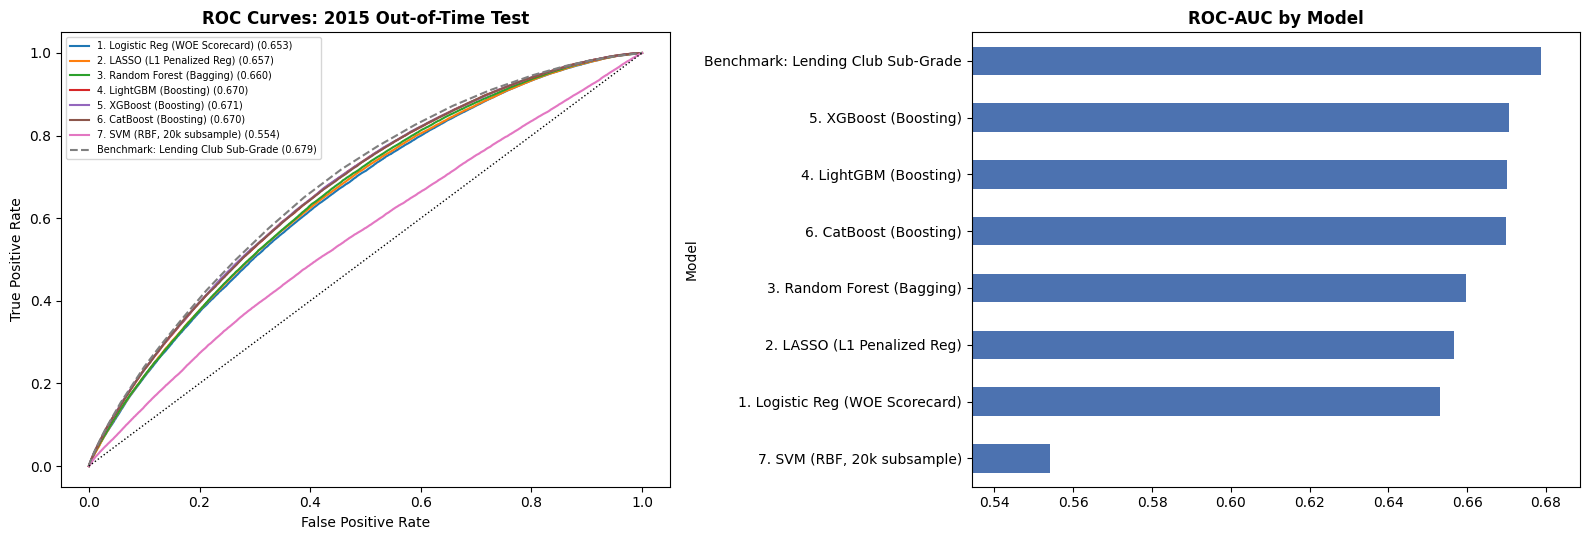

In [ ]:
print("--- Training Models & Evaluating on the 2015 Vintage ---")

def ks_stat(y, p):
    return ks_2samp(p[y == 1], p[y == 0]).statistic * 100

# 1. SVM subsample (training time grows ~quadratically with n)
svm_idx = np.random.default_rng(42).choice(len(train), size=min(20000, len(train)), replace=False)

models = {
    "1. Logistic Reg (WOE Scorecard)": (LogisticRegression(C=0.1, max_iter=1000), X_train_woe, X_test_woe, None),
    "2. LASSO (L1 Penalized Reg)": (LogisticRegression(penalty='l1', solver='liblinear', C=0.01), X_train_scaled, X_test_scaled, None),
    "3. Random Forest (Bagging)": (RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50, n_jobs=-1, random_state=42),
                                   X_train_tree.fillna(-999), X_test_tree.fillna(-999), None),
    "4. LightGBM (Boosting)": (lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
                               X_train_tree, X_test_tree, None),
    "5. XGBoost (Boosting)": (XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='auc'),
                              X_train_tree, X_test_tree, None),
    "6. CatBoost (Boosting)": (CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0),
                               X_train_tree, X_test_tree, None),
    "7. SVM (RBF, 20k subsample)": (SVC(probability=True, random_state=42), X_train_scaled, X_test_scaled, svm_idx),
}

results, test_preds = [], {}
for name, (model, X_tr, X_te, subsample) in models.items():
    start = time.time()
    print(f"Training {name}...", end=" ")
    if subsample is not None:
        model.fit(X_tr[subsample], y_train[subsample])
    else:
        model.fit(X_tr, y_train)
    p = model.predict_proba(X_te)[:, 1]
    elapsed = time.time() - start
    auc = roc_auc_score(y_test, p)
    test_preds[name] = p
    results.append({'Model': name, 'ROC-AUC': auc, 'Gini': 2 * auc - 1, 'KS': ks_stat(y_test, p),
                    'Brier Score': brier_score_loss(y_test, p), 'Mean PD': p.mean(), 'Training Time (s)': elapsed})
    print(f"Done! (AUC: {auc:.4f}, Time: {elapsed:.1f}s)")

# 2. External benchmark: Lending Club's own sub-grade
subgrade_pd = train.groupby('sub_grade')['TARGET'].mean()
p_lc = test['sub_grade'].map(subgrade_pd).fillna(y_train.mean()).values
auc_lc = roc_auc_score(y_test, p_lc)
test_preds["Benchmark: Lending Club Sub-Grade"] = p_lc
results.append({'Model': "Benchmark: Lending Club Sub-Grade", 'ROC-AUC': auc_lc, 'Gini': 2 * auc_lc - 1,
                'KS': ks_stat(y_test, p_lc), 'Brier Score': brier_score_loss(y_test, p_lc),
                'Mean PD': p_lc.mean(), 'Training Time (s)': np.nan})

# 3. Final comparison table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f"\nActual 2015 default rate: {y_test.mean():.2%}")
print("\n--- Final Model Benchmark Comparison (Out-of-Time: 2015 Vintage) ---")
display(results_df.round(4))

# 4. ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for name, p in test_preds.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, p):.3f})", ls='--' if 'Benchmark' in name else '-')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves: 2015 Out-of-Time Test', fontweight='bold'); axes[0].legend(fontsize=7)
results_df.set_index('Model')['ROC-AUC'].sort_values().plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set_xlim(results_df['ROC-AUC'].min() - 0.02, results_df['ROC-AUC'].max() + 0.01)
axes[1].set_title('ROC-AUC by Model', fontweight='bold')
plt.tight_layout(); plt.show()

## Conclusion:
1. **Gradient boosting leads the models.** XGBoost, LightGBM and CatBoost are almost tied (AUC 0.670–0.671, KS about 24.6–24.8). Their shared edge over the linear models comes from non-linear effects and interactions, for example FICO mattering differently at different income levels.

2. **The WOE scorecard is close behind.** The scorecard has the lowest AUC among the practical models (0.653). The gap to boosting is **0.017 AUC**, more than the 0.01 rule of thumb. That is a real but modest gain, and a bank would weigh it against the scorecard's transparency.

3. **Lending Club's sub-grade is the best "model" (AUC 0.679, KS 26.2).** It was built with full credit-bureau data that the public dataset does not contain. Our best model gets within **0.008 AUC** of it using only public application fields, which is a solid result.

4. **Calibration is equally good, and equally biased.** The Brier scores are almost identical (0.121–0.122). All models predict a mean PD of 13.3–13.5% against an actual **14.9%**. The problem is the population shift, not the algorithm, and Part 2 addresses it.

5. **SVM fails the practicality test.** Even on a 20,000-loan subsample, it took 542 seconds (30× longer than LightGBM on the full 330,000 loans) and delivered the worst AUC (0.554).

# Executive Summary

This benchmark evaluated seven classification algorithms and Lending Club's own sub-grade on a strict out-of-time test. The models were trained on **329,719 loans from the 2010–2014 vintages** and tested on the **283,026 loans of the 2015 vintage** (default rate 14.9%).

## Model Performance Ranking (Out-of-Time: 2015 Vintage)

| Rank | Algorithm | ROC-AUC | Gini | KS | Brier | Time (s) |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | XGBoost (Boosting) | 0.6707 | 0.342 | 24.8 | 0.1211 | 20.4 |
| 2 | LightGBM (Boosting) | 0.6700 | 0.340 | 24.7 | 0.1211 | 17.9 |
| 3 | CatBoost (Boosting) | 0.6699 | 0.340 | 24.6 | 0.1212 | 28.4 |
| 4 | Random Forest (Bagging) | 0.6598 | 0.320 | 23.3 | 0.1223 | 126.4 |
| 5 | LASSO (L1 Penalized Reg) | 0.6566 | 0.313 | 22.6 | 0.1222 | 3.2 |
| 6 | Logistic Reg (WOE Scorecard) | 0.6530 | 0.306 | 22.0 | 0.1223 | 1.2 |
| 7 | SVM (RBF, 20k subsample) | 0.5542 | 0.108 | 8.8 | 0.1268 | 542.2 |
| – | **Lending Club Sub-Grade (benchmark)** | **0.6786** | **0.357** | **26.2** | 0.1211 | – |

> **Key Takeaway:** Gradient boosting (XGBoost, LightGBM, CatBoost) is the most accurate family, beating the WOE scorecard by about 0.017 AUC. **LightGBM** offers the best balance of accuracy and speed (0.670 AUC in 18 seconds). No model built on public application data beats Lending Club's own sub-grade (0.679), which used richer credit-bureau data.

---

## Efficiency & Practicality

* **Fastest:** the WOE scorecard (1.2 s) and LASSO (3.2 s). They are cheap to train, monitor and explain.
* **Best trade-off:** LightGBM, with near-top accuracy at 18 seconds.
* **Bottlenecks:** Random Forest (126 s) is slow for a lower AUC. SVM (542 s on only 20,000 loans) is unusable at this scale.

## Lessons for Model Development

1. **Out-of-time testing matters.** The 2015 vintage was riskier than its predecessors (14.9% vs. 13.1% default), so every model under-predicts PD by about 10%. A random split would have hidden this.
2. **Discrimination is capped by pre-screening.** Lending Club had already rejected the riskiest applicants, so the approved borrowers are hard to separate (best KS about 25). Scoring the full applicant population would require the rejected applications (reject inference).
3. **Champion–challenger.** A bank would likely keep an interpretable scorecard as the champion and use LightGBM as a challenger and benchmark. Part 2 builds both and tests whether the boosting gain translates into money.